decodability of angles of interest across sessions & conditions

In [122]:
from behave_analysis.database.Experiments.JAL003_ex import flip1stSept_003, JAL3_flip_rot, flip4stSept_003

from behave_analysis.database.Experiments.JAL004_ex import JAL4_mush1, JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept

from behave_analysis.database.Experiments.JAL005_ex import JAL5_mush1, JAL005_8thSept, JAL005_21stSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_hab_1mar, JAL6_shelt_4mar, JAL6_flip6

from behave_analysis.database.Experiments.JAL007_ex import JAL7_hab_1mar, JAL7_empty_shelter, JAL7_sesh8_9apr, JAL7_sesh9_16apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_shelt_22apr, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may

# ## -------------JR BEHAVIOR MICE

from behave_analysis.database.Experiments.Burrow_ex import burrow_3456, burrow_3440, burrow_3457, burrow_3457_2

# Currently the code only works with one experiment at a time, so place that experiment in the below list for analysis

# experiments_objects = [JAL4_3rdSept, JAL4_19thSept,JAL005_8thSept,JAL6_flip6,JAL7_sesh8_9apr,JAL8_flip1_25apr,JAL8_flip2_29apr]
experiments_objects = [JAL4_3rdSept, JAL4_19thSept,JAL005_8thSept,JAL6_flip6,JAL7_sesh8_9apr,JAL8_flip1_25apr,JAL8_flip2_29apr]

In [62]:
from behave_analysis.process.session import get_experiment 

In [63]:
import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt

In [123]:
'''From tracking data, extract random point positions and assign them to shelter or barrier'''

def tracking_to_features(tracking_data):
    features = {}
    ybins, y = np.unique(tracking_data["randP_loc"][:, 0], return_inverse=True)
    xbins, x = np.unique(tracking_data["randP_loc"][:, 1], return_inverse=True)
    heatmap = np.zeros(shape=(len(np.unique(tracking_data["randP_loc"][:, 0])), len(np.unique(tracking_data["randP_loc"][:, 1]))))

    # find random points that belong to shelter
    shelter_x_start = np.argmin(np.abs(xbins - tracking_data['shelter_loc'][0][0]))
    shelter_x_end = np.argmin(np.abs(xbins - tracking_data['shelter_loc'][1][0]))
    shelter_y_start = np.argmin(np.abs(ybins - tracking_data['shelter_loc'][0][1]))
    shelter_y_end = np.argmin(np.abs(ybins - tracking_data['shelter_loc'][1][1]))
    features['shelter'] = np.logical_and(np.logical_and(x>=shelter_x_start,x<=shelter_x_end),np.logical_and(y>=shelter_y_start,y<=shelter_y_end))
    heatmap[x, y] = np.ones(shape=(len(shelter)))
    heatmap[x[shelter], y[shelter]] = np.ones(shape=(np.sum(shelter)))*2

    # barrier random points
    feature_names = ['preflip_bar','postflip_bar']
    for i in [0,1]:
        barrier_x = np.sort(np.argsort(np.abs(xbins - tracking_data['barrier_loc'][i][0]))[:2])
        barrier_y = np.sort(np.argsort(np.abs(ybins - tracking_data['barrier_loc'][i][1]))[:2])
        features[feature_names[i]] = np.logical_and(np.logical_and(x>=barrier_x[0],x<=barrier_x[1]),np.logical_and(y>=barrier_y[0],y<=barrier_y[1]))
        heatmap[x[barrier], y[barrier]] = np.ones(shape=(np.sum(barrier)))*(3+i)

    return features

In [64]:
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"W:\branco\Laurence"

In [124]:
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a']
all_features = ['shelter','preflip_bar','postflip_bar']

sessy = {}
all_names = []
pa = {}
avg_pa = {}
for a in all_angles:
    pa[a] = np.empty((len(experiments_objects),len(conditions)))
for a in all_features:
    avg_pa[a] = np.empty((len(experiments_objects), len(conditions)))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = get_experiment(sesh)
    base_path = []
    if os.path.exists(os.path.join(ceph_path,session.processed_path)):
        base_path = ceph_path
    if os.path.exists(os.path.join(winstor_path,session.processed_path)):
        base_path = winstor_path
    
    # load tracking
    track_path = os.path.join(base_path,session.processed_path,r"fully_processed_tracking_data.pickle")
    with open(track_path, "rb") as dill_file:
        tracking_data = pickle.load(dill_file)
    features = tracking_to_features(tracking_data)

    # load prediction accuracy
    coef = {}
    for idx,c in enumerate(conditions):
        coef_path = os.path.join(base_path,session.processed_path,r'models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all',c,str('good_' + c + '_LDA_prediction_accuracy.pkl'))
        with open(coef_path, "rb") as dill_file:
            coef[c] = pickle.load(dill_file)
        point_grid = []
        for a in coef[c].keys():
            if a in all_angles:
                pa[a][s,idx] = coef[c][a]
            if 'rand' in a:
                point_grid.append(coef[c][a])
        
        # avrage random point pred.acc. for shelter and barrier
        point_grid = np.array(point_grid)
        for a in features.keys():
            avg_pa[a][s,idx] = np.mean(point_grid[features[a]])

    name = sesh.nick_name + '_' + sesh.experiment_date
    all_names.append(name)
    sessy[name] = coef

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_9136\2768479685.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")


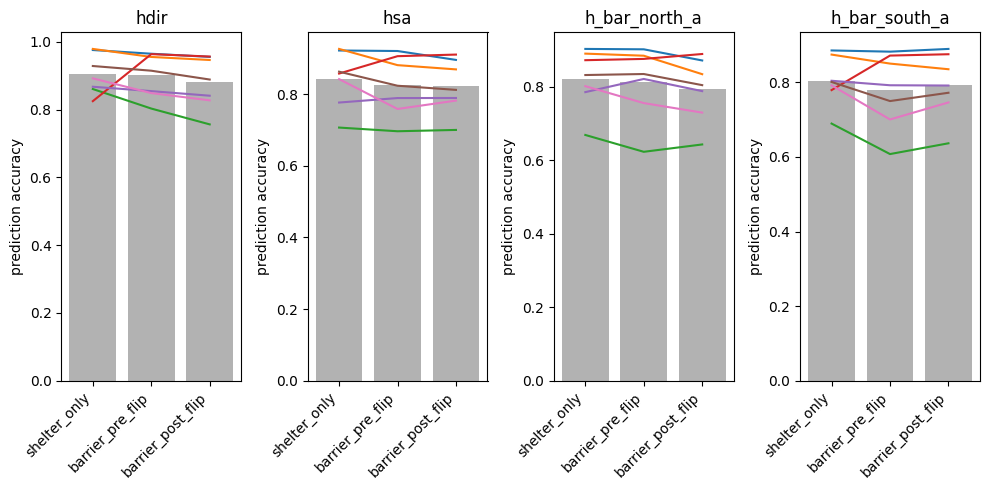

In [132]:
'''Plot the predicton accuracy for all sessions for the standard angles'''
fig, axs = plt.subplots(1,len(all_angles))
plt.rcParams['figure.figsize'] = [10, 5]
for idx, a in enumerate(all_angles):
    axs[idx].plot(conditions,pa[a].T)
    axs[idx].bar(conditions,np.mean(pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_ylabel('prediction accuracy')
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
plt.tight_layout()

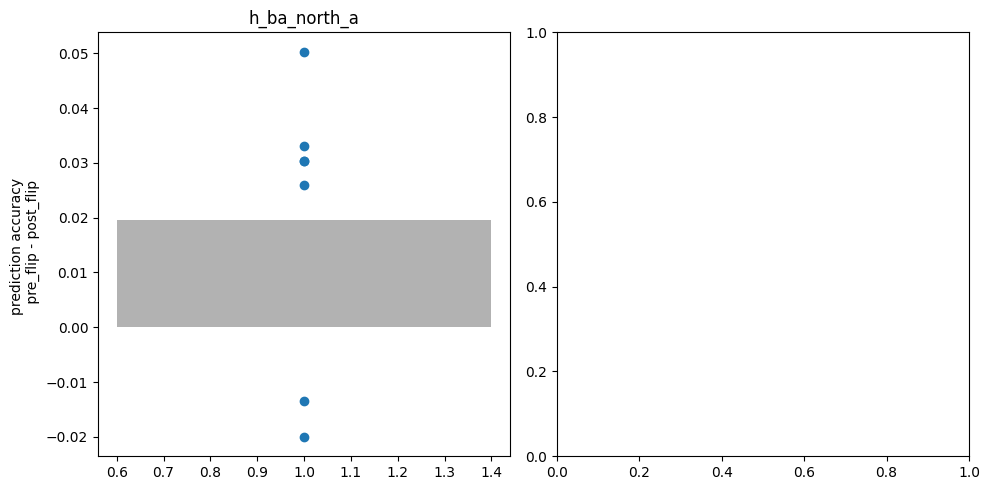

In [142]:
bar_north = pa['h_preflipbar_a'][:,1] - pa['h_preflipbar_a'][:,2]
bar_south = pa['h_postflipbar_a'][:,1] - pa['h_postflipbar_a'][:,2]
fig, axs = plt.subplots(1,2)
axs[0].bar(1,np.mean(bar_north),color = 'k',alpha = .3)
axs[0].scatter(np.ones(len(bar_north)),bar_north)
axs[0].set_title('h_preflipbar_a')
axs[0].set_ylabel('prediction accuracy \n pre_flip - post_flip')
plt.tight_layout()

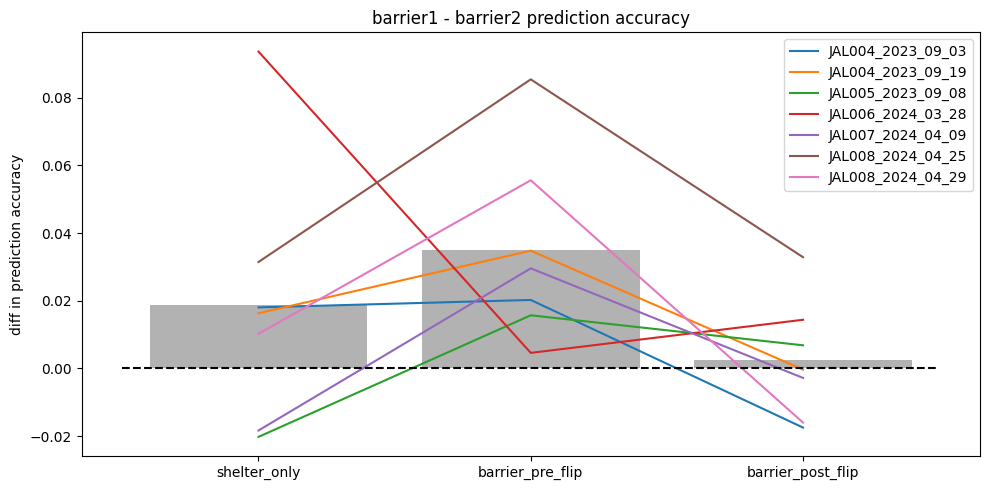

In [139]:
diff = pa['h_preflipbar_a'] - pa['h_postflipbar_a']
plt.plot(conditions,diff.T)
plt.bar(conditions,np.mean(diff,axis=0),color = 'k',alpha = .3)
plt.plot([-.5,2.5],[0,0],'--k')
plt.title('preflip_bar - postflip_bar prediction accuracy')
plt.ylabel('diff in prediction accuracy')
plt.legend(all_names)
plt.tight_layout()

C:\Users\jreggiani\AppData\Local\Temp\ipykernel_9136\4026818106.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")


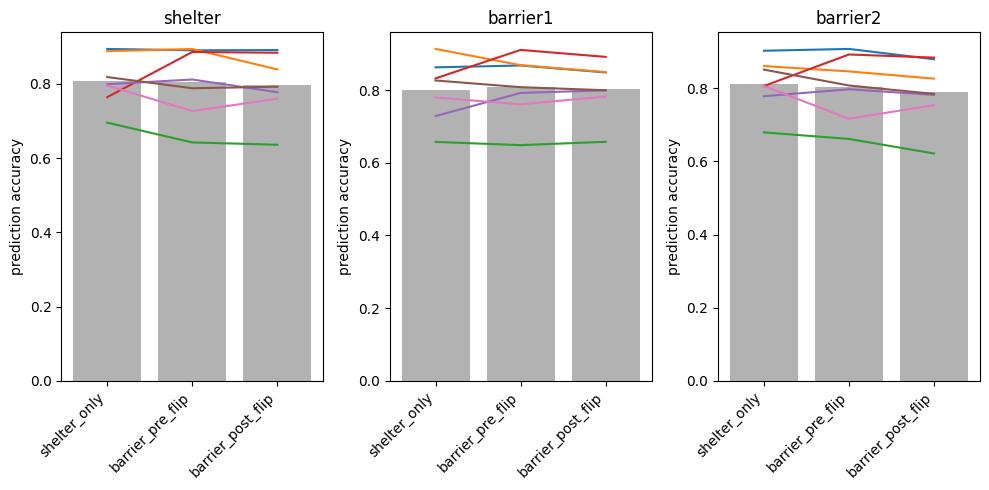

In [134]:
'''Plot the predicton accuracy for all sessions for the averaged angles'''
fig, axs = plt.subplots(1,len(all_features))
plt.rcParams['figure.figsize'] = [10, 5]
for idx, a in enumerate(all_features):
    axs[idx].plot(conditions,avg_pa[a].T)
    axs[idx].bar(conditions,np.mean(avg_pa[a],axis=0),color = 'k',alpha = .3)
    axs[idx].set_title(a)
    axs[idx].set_ylabel('prediction accuracy')
    axs[idx].set_xticklabels(conditions,rotation = 45, ha="right")
plt.tight_layout()

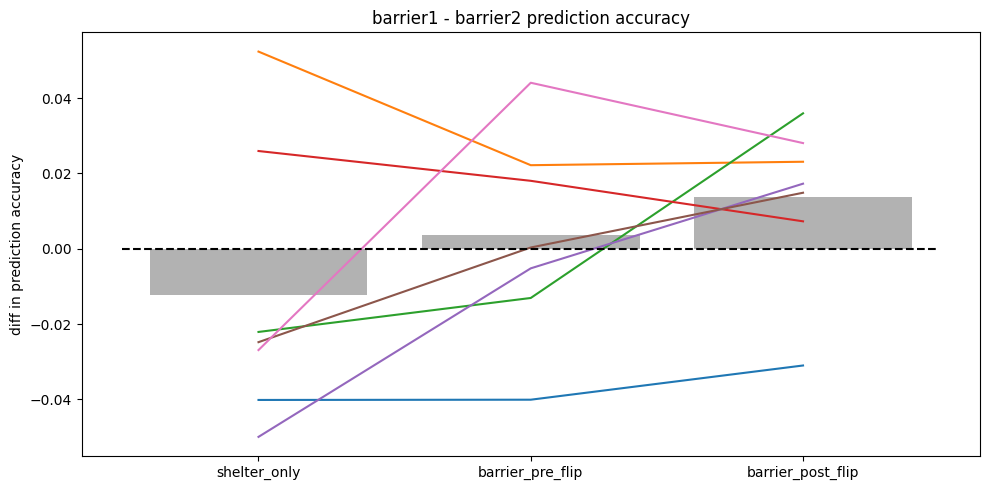

In [135]:
diff = avg_pa['preflip_bar'] - avg_pa['postflip_bar']
plt.plot(conditions,diff.T)
plt.bar(conditions,np.mean(diff,axis=0),color = 'k',alpha = .3)
plt.plot([-.5,2.5],[0,0],'--k')
plt.title('preflip_bar - postflip_bar prediction accuracy')
plt.ylabel('diff in prediction accuracy')
plt.tight_layout()

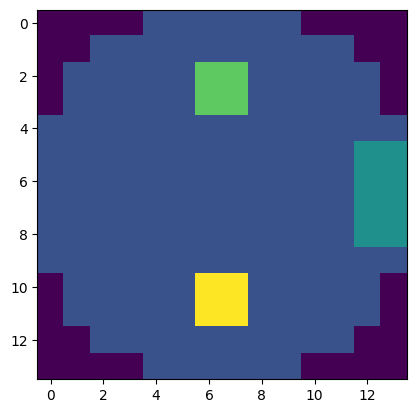

In [77]:
'''Find the random points that belong to the shelter - for averaging across'''
shelter_x_start = np.argmin(np.abs(xbins - tracking_data['shelter_loc'][0][0]))
shelter_x_end = np.argmin(np.abs(xbins - tracking_data['shelter_loc'][1][0]))
shelter_y_start = np.argmin(np.abs(ybins - tracking_data['shelter_loc'][0][1]))
shelter_y_end = np.argmin(np.abs(ybins - tracking_data['shelter_loc'][1][1]))
heatmap = np.zeros(shape=(len(np.unique(tracking_data["randP_loc"][:, 0])), len(np.unique(tracking_data["randP_loc"][:, 1]))))
shelter = np.logical_and(np.logical_and(x>=shelter_x_start,x<=shelter_x_end),np.logical_and(y>=shelter_y_start,y<=shelter_y_end))
heatmap[x, y] = np.ones(shape=(len(shelter)))
heatmap[x[shelter], y[shelter]] = np.ones(shape=(np.sum(shelter)))*2

# Find the random points that belong to the barrier edge - for averaging across
for i in [0,1]:
    barrier_x = np.sort(np.argsort(np.abs(xbins - tracking_data['barrier_loc'][i][0]))[:2])
    barrier_y = np.sort(np.argsort(np.abs(ybins - tracking_data['barrier_loc'][i][1]))[:2])
    barrier = np.logical_and(np.logical_and(x>=barrier_x[0],x<=barrier_x[1]),np.logical_and(y>=barrier_y[0],y<=barrier_y[1]))
    heatmap[x[barrier], y[barrier]] = np.ones(shape=(np.sum(barrier)))*(3+i)

plt.imshow(heatmap)